<a href="https://colab.research.google.com/github/drfperez/openair/blob/main/Dim_figuras_2_ok.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- PARTE 1: DESDE SERVIDORES HASTA BD CONJUNTA ---


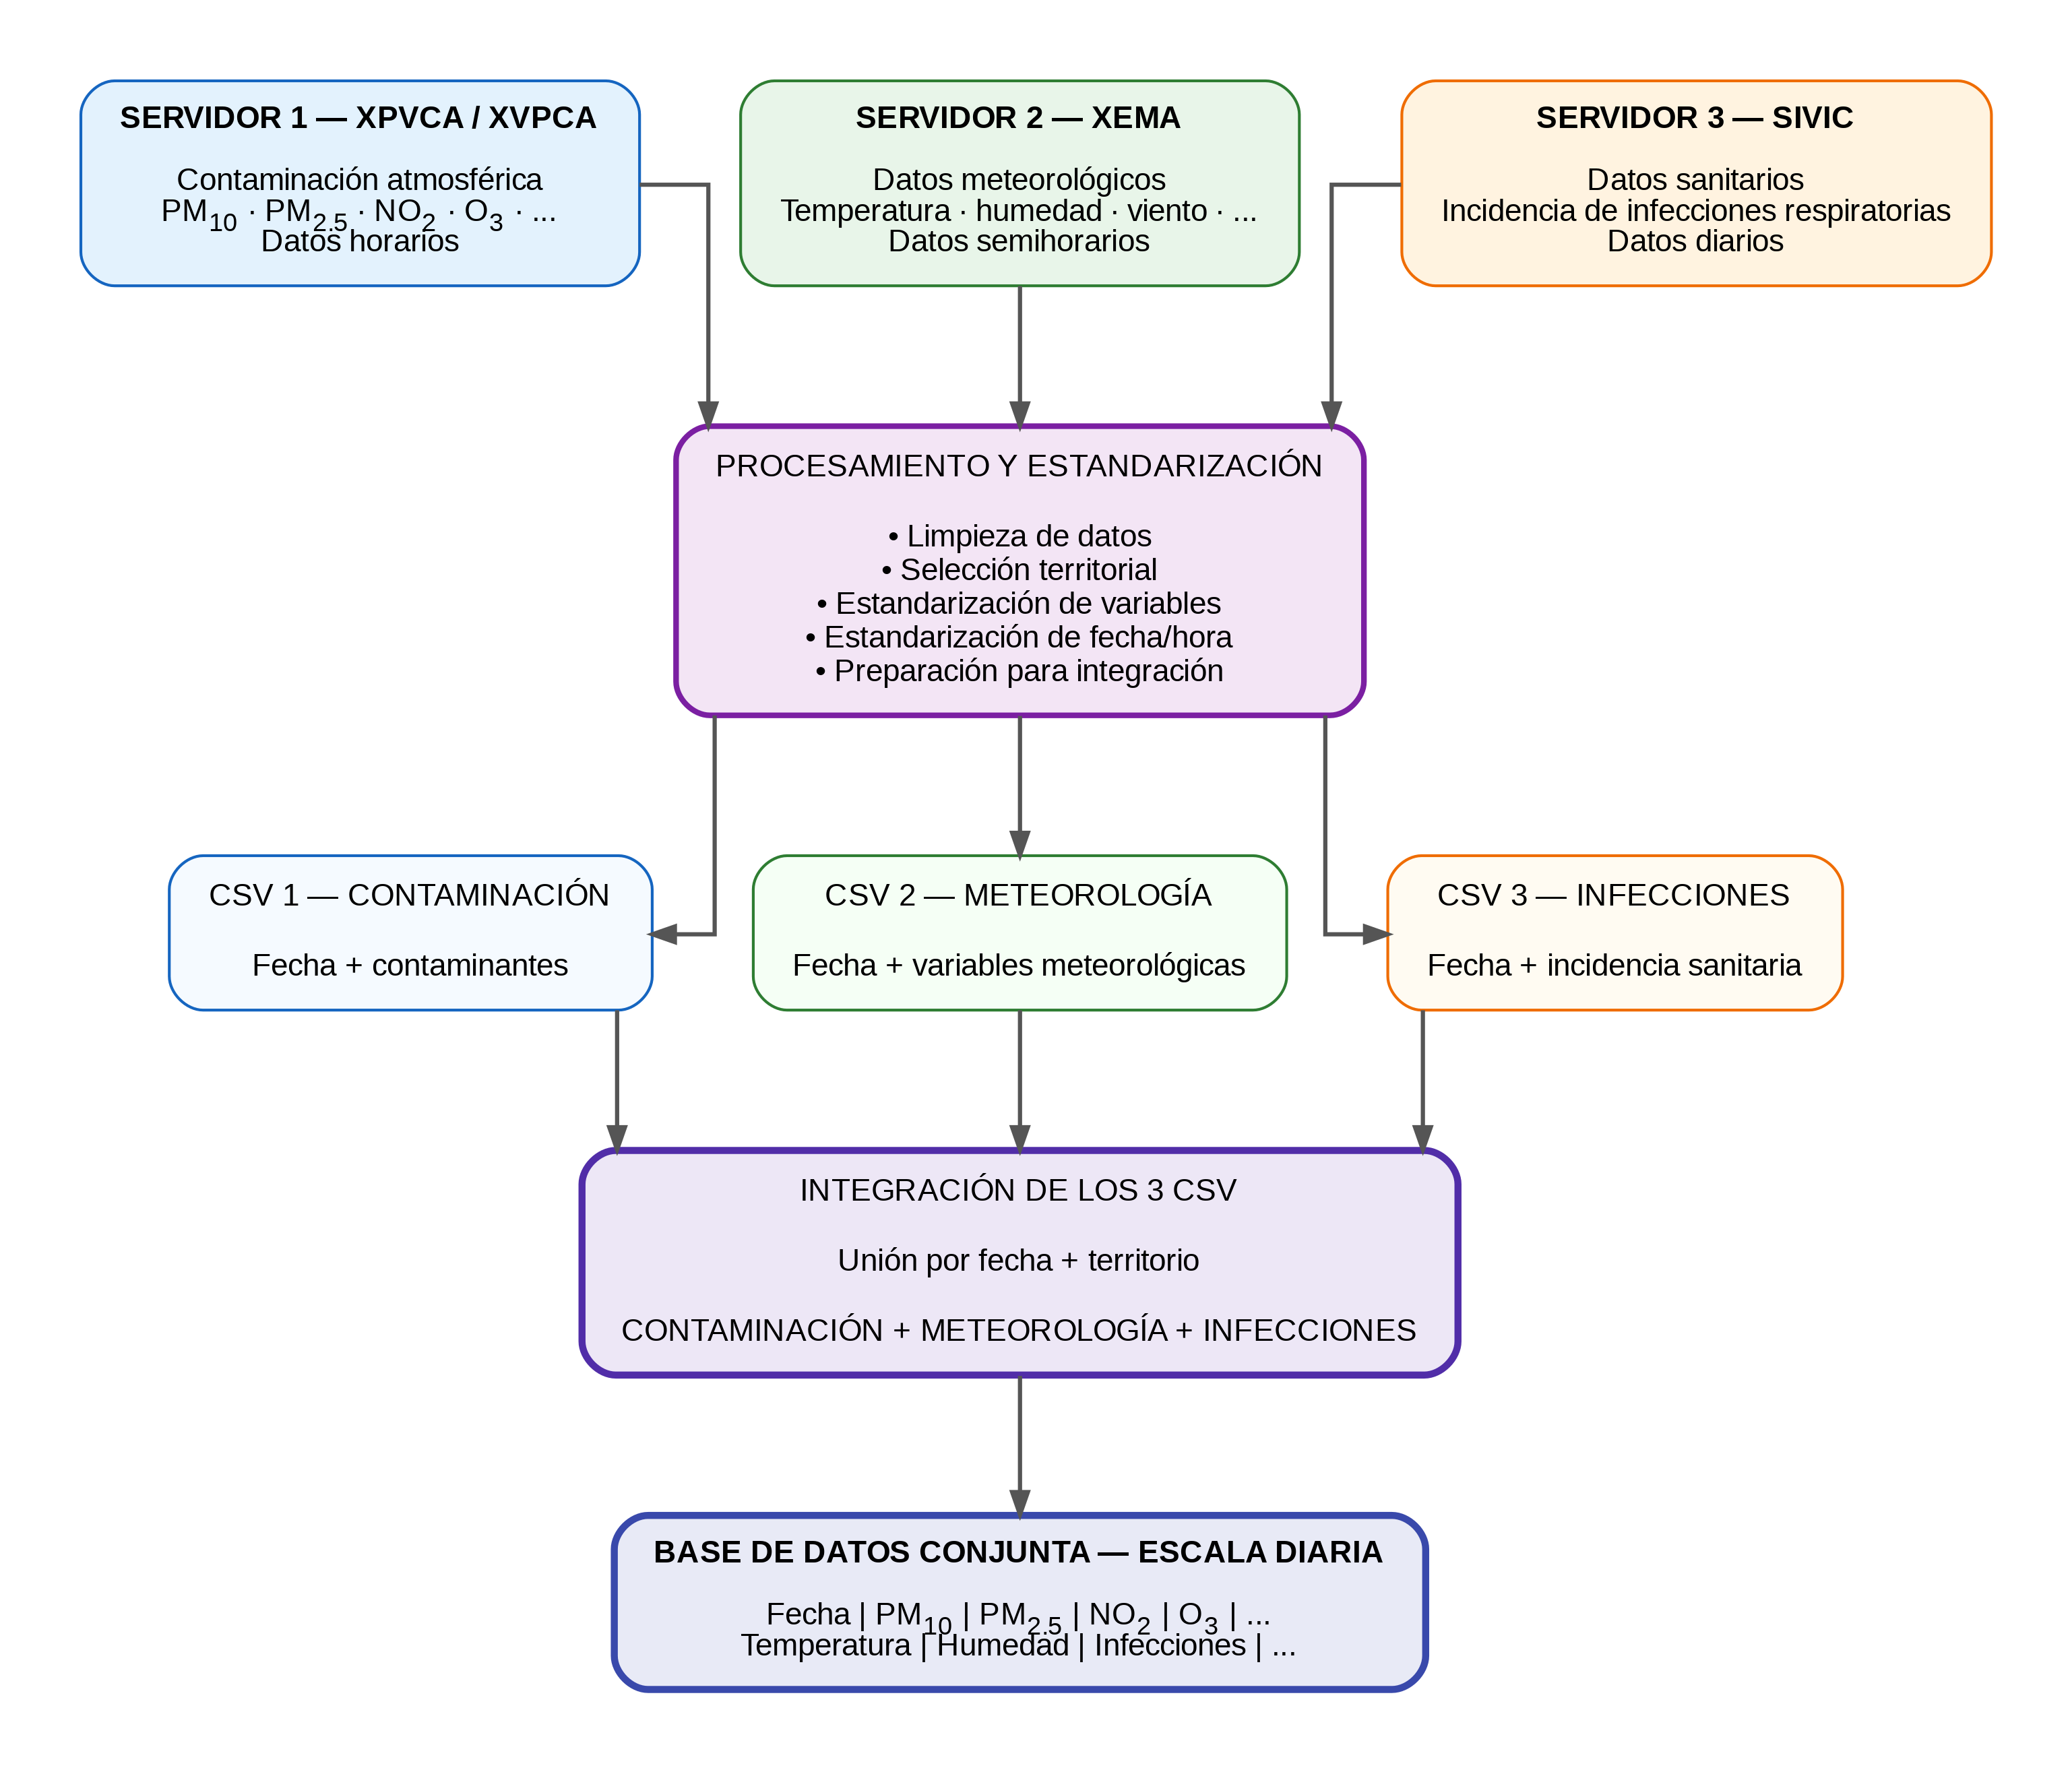


--- PARTE 2: DESDE BD CONJUNTA HASTA DIFUSIÓN ---


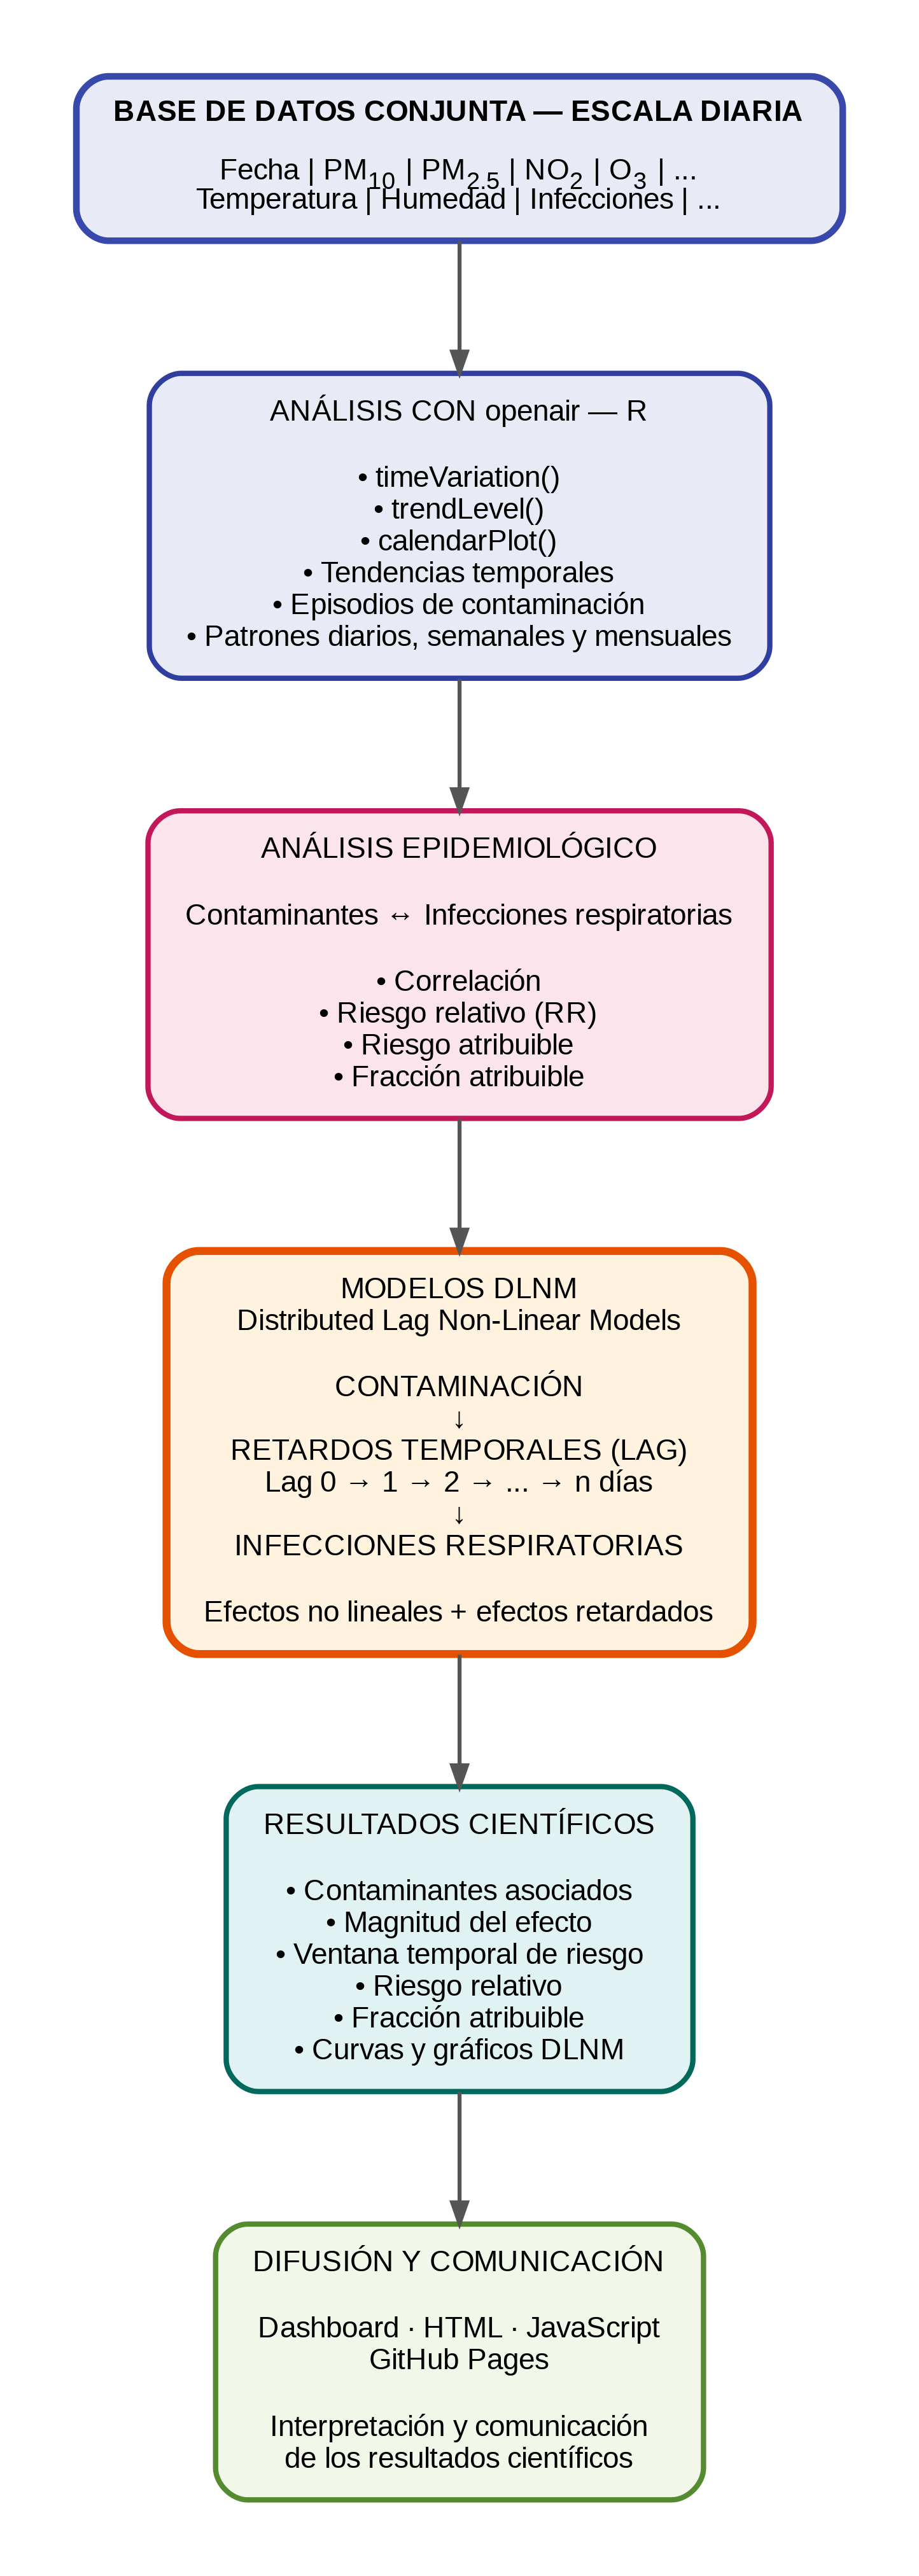

In [4]:

# ============================================================
# DIAGRAMA DE FLUJO - EPIDEMIOLOGÍA AMBIENTAL (EN 2 PARTES)
# ORIENTACIÓN: ARRIBA → ABAJO | RESOLUCIÓN: 300 DPI
# Google Colab + Graphviz
# ============================================================

!apt-get -qq install graphviz
!pip install -q graphviz

from graphviz import Digraph
from IPython.display import display, Image

# Estilos globales para ambos diagramas
def aplicar_estilos_base(dot):
    dot.attr(
        rankdir="TB",
        bgcolor="white",
        pad="0.4",
        nodesep="0.5",
        ranksep="0.7",
        splines="ortho",
        dpi="300"  # Alta resolución (300 DPI)
    )
    dot.attr(
        "node",
        shape="box",
        style="rounded,filled",
        fontname="Arial",
        fontsize="11",
        margin="0.2,0.12"
    )
    dot.attr(
        "edge",
        color="#555555",
        penwidth="1.5",
        arrowsize="0.8",
        fontname="Arial",
        fontsize="9"
    )

# ============================================================
# PARTE 1: SERVIDORES DE DATOS → BASE DE DATOS CONJUNTA
# ============================================================

dot1 = Digraph("flujo_parte_1", format="png")
aplicar_estilos_base(dot1)

# Nodos Parte 1
dot1.node(
    "xpvca",
    "<<b>SERVIDOR 1 — XPVCA / XVPCA</b><br/><br/>"
    "Contaminación atmosférica<br/>"
    "PM<sub>10</sub> · PM<sub>2.5</sub> · NO<sub>2</sub> · O<sub>3</sub> · ...<br/>"
    "Datos horarios>",
    fillcolor="#E3F2FD",
    color="#1565C0"
)

dot1.node(
    "xema",
    "<<b>SERVIDOR 2 — XEMA</b><br/><br/>"
    "Datos meteorológicos<br/>"
    "Temperatura · humedad · viento · ...<br/>"
    "Datos semihorarios>",
    fillcolor="#E8F5E9",
    color="#2E7D32"
)

dot1.node(
    "sivic",
    "<<b>SERVIDOR 3 — SIVIC</b><br/><br/>"
    "Datos sanitarios<br/>"
    "Incidencia de infecciones respiratorias<br/>"
    "Datos diarios>",
    fillcolor="#FFF3E0",
    color="#EF6C00"
)

dot1.node(
    "procesamiento",
    "PROCESAMIENTO Y ESTANDARIZACIÓN\n\n"
    "• Limpieza de datos\n"
    "• Selección territorial\n"
    "• Estandarización de variables\n"
    "• Estandarización de fecha/hora\n"
    "• Preparación para integración",
    fillcolor="#F3E5F5",
    color="#7B1FA2",
    penwidth="2"
)

dot1.node(
    "csv_air",
    "CSV 1 — CONTAMINACIÓN\n\nFecha + contaminantes",
    fillcolor="#F5FAFF",
    color="#1565C0"
)

dot1.node(
    "csv_weather",
    "CSV 2 — METEOROLOGÍA\n\nFecha + variables meteorológicas",
    fillcolor="#F5FFF5",
    color="#2E7D32"
)

dot1.node(
    "csv_health",
    "CSV 3 — INFECCIONES\n\nFecha + incidencia sanitaria",
    fillcolor="#FFFBF2",
    color="#EF6C00"
)

dot1.node(
    "merge",
    "INTEGRACIÓN DE LOS 3 CSV\n\n"
    "Unión por fecha + territorio\n\n"
    "CONTAMINACIÓN + METEOROLOGÍA + INFECCIONES",
    fillcolor="#EDE7F6",
    color="#512DA8",
    penwidth="2.5"
)

dot1.node(
    "daily",
    "<<b>BASE DE DATOS CONJUNTA — ESCALA DIARIA</b><br/><br/>"
    "Fecha | PM<sub>10</sub> | PM<sub>2.5</sub> | NO<sub>2</sub> | O<sub>3</sub> | ...<br/>"
    "Temperatura | Humedad | Infecciones | ...>",
    fillcolor="#E8EAF6",
    color="#3949AB",
    penwidth="2.5"
)

# Conexiones Parte 1
dot1.edge("xpvca", "procesamiento")
dot1.edge("xema", "procesamiento")
dot1.edge("sivic", "procesamiento")

dot1.edge("procesamiento", "csv_air")
dot1.edge("procesamiento", "csv_weather")
dot1.edge("procesamiento", "csv_health")

dot1.edge("csv_air", "merge")
dot1.edge("csv_weather", "merge")
dot1.edge("csv_health", "merge")

dot1.edge("merge", "daily")

# Renderizar y guardar Parte 1
dot1.render("/content/flujo_parte1_bd_conjunta", cleanup=True)


# ============================================================
# PARTE 2: BASE DE DATOS CONJUNTA → DIFUSIÓN Y COMUNICACIÓN
# ============================================================

dot2 = Digraph("flujo_parte_2", format="png")
aplicar_estilos_base(dot2)

# Nodos Parte 2
dot2.node(
    "daily",
    "<<b>BASE DE DATOS CONJUNTA — ESCALA DIARIA</b><br/><br/>"
    "Fecha | PM<sub>10</sub> | PM<sub>2.5</sub> | NO<sub>2</sub> | O<sub>3</sub> | ...<br/>"
    "Temperatura | Humedad | Infecciones | ...>",
    fillcolor="#E8EAF6",
    color="#3949AB",
    penwidth="2.5"
)

dot2.node(
    "openair",
    "ANÁLISIS CON openair — R\n\n"
    "• timeVariation()\n"
    "• trendLevel()\n"
    "• calendarPlot()\n"
    "• Tendencias temporales\n"
    "• Episodios de contaminación\n"
    "• Patrones diarios, semanales y mensuales",
    fillcolor="#E8EAF6",
    color="#303F9F",
    penwidth="2"
)

dot2.node(
    "epi",
    "ANÁLISIS EPIDEMIOLÓGICO\n\n"
    "Contaminantes ↔ Infecciones respiratorias\n\n"
    "• Correlación\n"
    "• Riesgo relativo (RR)\n"
    "• Riesgo atribuible\n"
    "• Fracción atribuible",
    fillcolor="#FCE4EC",
    color="#C2185B",
    penwidth="2"
)

dot2.node(
    "dlnm",
    "MODELOS DLNM\n"
    "Distributed Lag Non-Linear Models\n\n"
    "CONTAMINACIÓN\n"
    "↓\n"
    "RETARDOS TEMPORALES (LAG)\n"
    "Lag 0 → 1 → 2 → ... → n días\n"
    "↓\n"
    "INFECCIONES RESPIRATORIAS\n\n"
    "Efectos no lineales + efectos retardados",
    fillcolor="#FFF3E0",
    color="#E65100",
    penwidth="3"
)

dot2.node(
    "results",
    "RESULTADOS CIENTÍFICOS\n\n"
    "• Contaminantes asociados\n"
    "• Magnitud del efecto\n"
    "• Ventana temporal de riesgo\n"
    "• Riesgo relativo\n"
    "• Fracción atribuible\n"
    "• Curvas y gráficos DLNM",
    fillcolor="#E0F2F1",
    color="#00695C",
    penwidth="2"
)

dot2.node(
    "web",
    "DIFUSIÓN Y COMUNICACIÓN\n\n"
    "Dashboard · HTML · JavaScript\n"
    "GitHub Pages\n\n"
    "Interpretación y comunicación\n"
    "de los resultados científicos",
    fillcolor="#F1F8E9",
    color="#558B2F",
    penwidth="2"
)

# Conexiones Parte 2
dot2.edge("daily", "openair")
dot2.edge("openair", "epi")
dot2.edge("epi", "dlnm")
dot2.edge("dlnm", "results")
dot2.edge("results", "web")

# Renderizar y guardar Parte 2
dot2.render("/content/flujo_parte2_analisis_difusion", cleanup=True)

# ============================================================
# MOSTRAR EN COLAB
# ============================================================

print("--- PARTE 1: DESDE SERVIDORES HASTA BD CONJUNTA ---")
display(Image("/content/flujo_parte1_bd_conjunta.png"))

print("\n--- PARTE 2: DESDE BD CONJUNTA HASTA DIFUSIÓN ---")
display(Image("/content/flujo_parte2_analisis_difusion.png"))

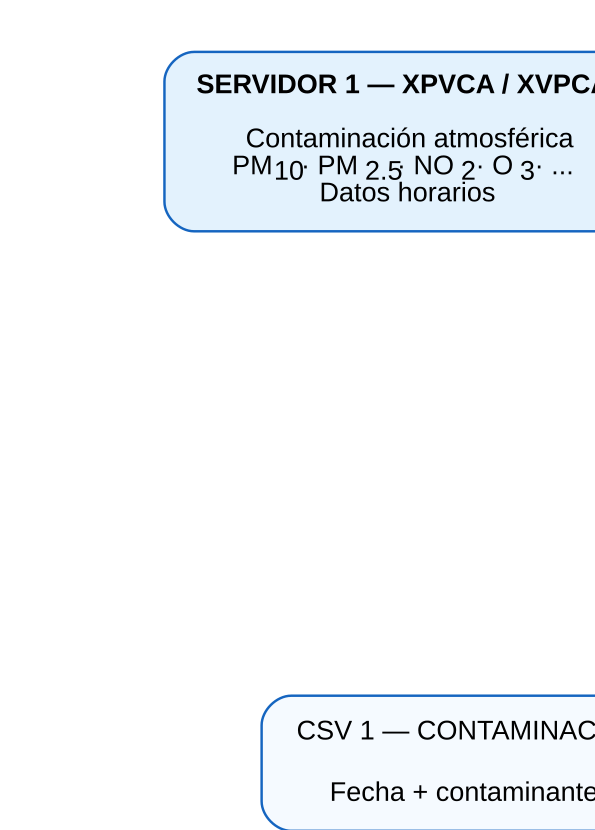

PNG guardado correctamente en:
/content/flujo_epidemiologia_ambiental_a4.png


In [2]:

# ============================================================
# DIAGRAMA DEL FLUJO DE TRABAJO - EPIDEMIOLOGÍA AMBIENTAL
# ORIENTACIÓN: ARRIBA → ABAJO | FORMATO: DIN A4
# Google Colab + Graphviz
# ============================================================

!apt-get -qq install graphviz
!pip install -q graphviz

from graphviz import Digraph
from IPython.display import display

# ------------------------------------------------------------
# CREAR DIAGRAMA
# ------------------------------------------------------------

dot = Digraph(
    "flujo_epidemiologia_ambiental",
    format="png"
)

# ------------------------------------------------------------
# CONFIGURACIÓN TAMAÑO DIN A4 (8.27 x 11.69 PULGADAS)
# ------------------------------------------------------------
dot.attr(
    rankdir="TB",
    bgcolor="white",
    pad="0.3",
    nodesep="0.4",
    ranksep="0.6",
    splines="ortho",
    size="8.27,11.69!",  # Forzar proporción DIN A4
    ratio="fill",        # Ajustar contenido al A4
    dpi="300"            # Alta resolución
)

# Estilo de nodos
dot.attr(
    "node",
    shape="box",
    style="rounded,filled",
    fontname="Arial",
    fontsize="11",
    margin="0.18,0.12"
)

# Estilo de flechas
dot.attr(
    "edge",
    color="#555555",
    penwidth="1.5",
    arrowsize="0.8",
    fontname="Arial",
    fontsize="9"
)

# ============================================================
# 1. SERVIDORES DE DATOS
# ============================================================

dot.node(
    "xpvca",
    "<<b>SERVIDOR 1 — XPVCA / XVPCA</b><br/><br/>"
    "Contaminación atmosférica<br/>"
    "PM<sub>10</sub> · PM<sub>2.5</sub> · NO<sub>2</sub> · O<sub>3</sub> · ...<br/>"
    "Datos horarios>",
    fillcolor="#E3F2FD",
    color="#1565C0"
)

dot.node(
    "xema",
    "<<b>SERVIDOR 2 — XEMA</b><br/><br/>"
    "Datos meteorológicos<br/>"
    "Temperatura · humedad · viento · ...<br/>"
    "Datos semihorarios>",
    fillcolor="#E8F5E9",
    color="#2E7D32"
)

dot.node(
    "sivic",
    "<<b>SERVIDOR 3 — SIVIC</b><br/><br/>"
    "Datos sanitarios<br/>"
    "Incidencia de infecciones respiratorias<br/>"
    "Datos diarios>",
    fillcolor="#FFF3E0",
    color="#EF6C00"
)

# ============================================================
# 2. PROCESAMIENTO
# ============================================================

dot.node(
    "procesamiento",
    "PROCESAMIENTO Y ESTANDARIZACIÓN\n\n"
    "• Limpieza de datos\n"
    "• Selección territorial\n"
    "• Estandarización de variables\n"
    "• Estandarización de fecha/hora\n"
    "• Preparación para integración",
    fillcolor="#F3E5F5",
    color="#7B1FA2",
    penwidth="2"
)

# ============================================================
# 3. CSV INDIVIDUALES
# ============================================================

dot.node(
    "csv_air",
    "CSV 1 — CONTAMINACIÓN\n\n"
    "Fecha + contaminantes",
    fillcolor="#F5FAFF",
    color="#1565C0"
)

dot.node(
    "csv_weather",
    "CSV 2 — METEOROLOGÍA\n\n"
    "Fecha + variables meteorológicas",
    fillcolor="#F5FFF5",
    color="#2E7D32"
)

dot.node(
    "csv_health",
    "CSV 3 — INFECCIONES\n\n"
    "Fecha + incidencia sanitaria",
    fillcolor="#FFFBF2",
    color="#EF6C00"
)

# ============================================================
# 4. INTEGRACIÓN
# ============================================================

dot.node(
    "merge",
    "INTEGRACIÓN DE LOS 3 CSV\n\n"
    "Unión por fecha + territorio\n\n"
    "CONTAMINACIÓN + METEOROLOGÍA + INFECCIONES",
    fillcolor="#EDE7F6",
    color="#512DA8",
    penwidth="2.5"
)

# ============================================================
# 5. BASE DE DATOS CONJUNTA
# ============================================================

dot.node(
    "daily",
    "<<b>BASE DE DATOS CONJUNTA — ESCALA DIARIA</b><br/><br/>"
    "Fecha | PM<sub>10</sub> | PM<sub>2.5</sub> | NO<sub>2</sub> | O<sub>3</sub> | ...<br/>"
    "Temperatura | Humedad | Infecciones | ...>",
    fillcolor="#E8EAF6",
    color="#3949AB",
    penwidth="2"
)

# ============================================================
# 6. OPENAIR
# ============================================================

dot.node(
    "openair",
    "ANÁLISIS CON openair — R\n\n"
    "• timeVariation()\n"
    "• trendLevel()\n"
    "• calendarPlot()\n"
    "• Tendencias temporales\n"
    "• Episodios de contaminación\n"
    "• Patrones diarios, semanales y mensuales",
    fillcolor="#E8EAF6",
    color="#303F9F",
    penwidth="2"
)

# ============================================================
# 7. ANÁLISIS EPIDEMIOLÓGICO
# ============================================================

dot.node(
    "epi",
    "ANÁLISIS EPIDEMIOLÓGICO\n\n"
    "Contaminantes ↔ Infecciones respiratorias\n\n"
    "• Correlación\n"
    "• Riesgo relativo (RR)\n"
    "• Riesgo atribuible\n"
    "• Fracción atribuible",
    fillcolor="#FCE4EC",
    color="#C2185B",
    penwidth="2"
)

# ============================================================
# 8. DLNM
# ============================================================

dot.node(
    "dlnm",
    "MODELOS DLNM\n"
    "Distributed Lag Non-Linear Models\n\n"
    "CONTAMINACIÓN\n"
    "↓\n"
    "RETARDOS TEMPORALES (LAG)\n"
    "Lag 0 → 1 → 2 → ... → n días\n"
    "↓\n"
    "INFECCIONES RESPIRATORIAS\n\n"
    "Efectos no lineales + efectos retardados",
    fillcolor="#FFF3E0",
    color="#E65100",
    penwidth="3"
)

# ============================================================
# 9. RESULTADOS
# ============================================================

dot.node(
    "results",
    "RESULTADOS CIENTÍFICOS\n\n"
    "• Contaminantes asociados\n"
    "• Magnitud del efecto\n"
    "• Ventana temporal de riesgo\n"
    "• Riesgo relativo\n"
    "• Fracción atribuible\n"
    "• Curvas y gráficos DLNM",
    fillcolor="#E0F2F1",
    color="#00695C",
    penwidth="2"
)

# ============================================================
# 10. DIFUSIÓN
# ============================================================

dot.node(
    "web",
    "DIFUSIÓN Y COMUNICACIÓN\n\n"
    "Dashboard · HTML · JavaScript\n"
    "GitHub Pages\n\n"
    "Interpretación y comunicación\n"
    "de los resultados científicos",
    fillcolor="#F1F8E9",
    color="#558B2F",
    penwidth="2"
)

# ============================================================
# CONEXIONES
# ============================================================

dot.edge("xpvca", "procesamiento")
dot.edge("xema", "procesamiento")
dot.edge("sivic", "procesamiento")

dot.edge("procesamiento", "csv_air")
dot.edge("procesamiento", "csv_weather")
dot.edge("procesamiento", "csv_health")

dot.edge("csv_air", "merge")
dot.edge("csv_weather", "merge")
dot.edge("csv_health", "merge")

dot.edge("merge", "daily")
dot.edge("daily", "openair")
dot.edge("openair", "epi")
dot.edge("epi", "dlnm")
dot.edge("dlnm", "results")
dot.edge("results", "web")

# ============================================================
# MOSTRAR Y GUARDAR
# ============================================================

display(dot)

dot.render(
    "/content/flujo_epidemiologia_ambiental_a4",
    cleanup=True
)

print("PNG guardado correctamente en:")
print("/content/flujo_epidemiologia_ambiental_a4.png")

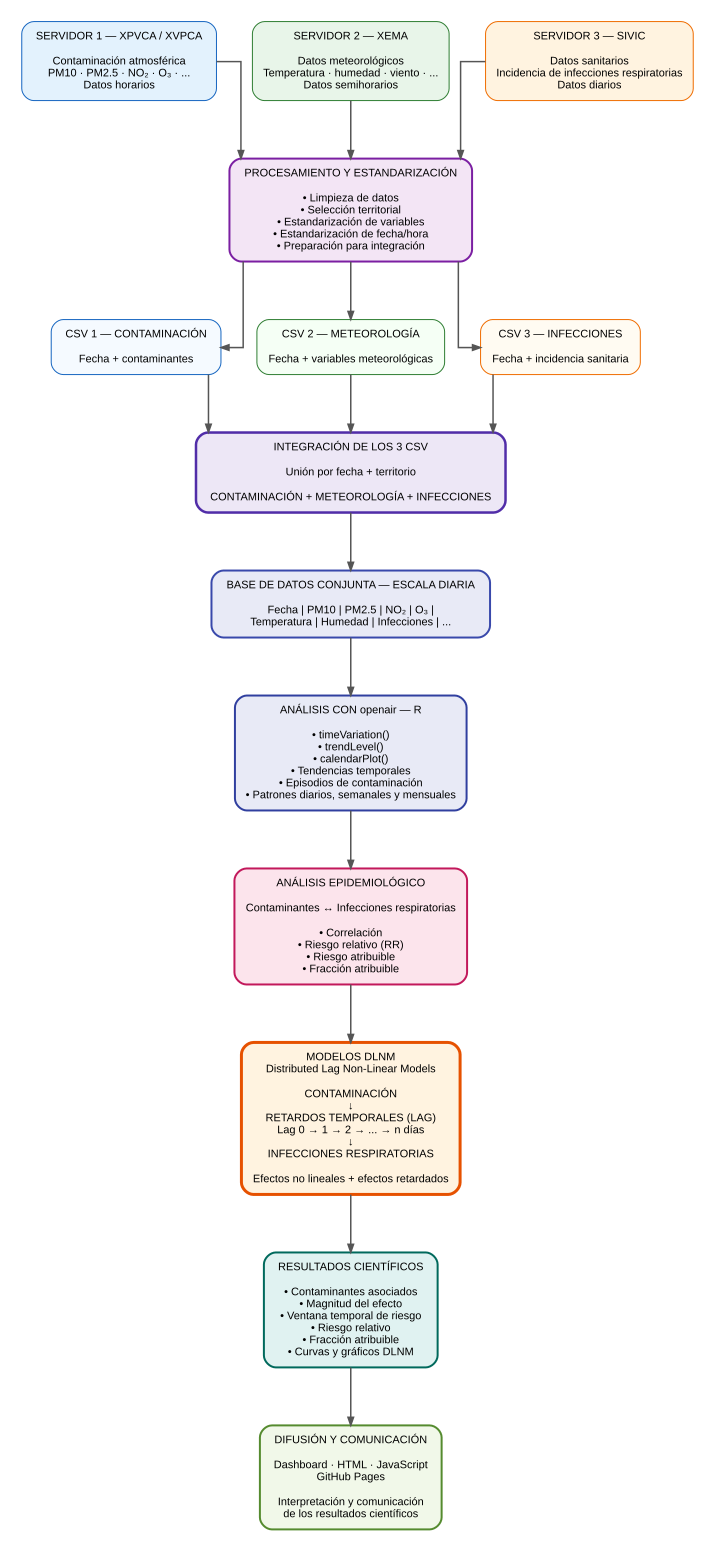

PNG guardado en:
/content/flujo_epidemiologia_ambiental_vertical.png


In [ ]:
# ============================================================
# DIAGRAMA DEL FLUJO DE TRABAJO - EPIDEMIOLOGÍA AMBIENTAL
# ORIENTACIÓN: ARRIBA → ABAJO
# Google Colab + Graphviz
# ============================================================

!apt-get -qq install graphviz
!pip install -q graphviz

from graphviz import Digraph
from IPython.display import display

# ------------------------------------------------------------
# CREAR DIAGRAMA
# ------------------------------------------------------------

dot = Digraph(
    "flujo_epidemiologia_ambiental",
    format="png"
)

# ARRIBA → ABAJO
dot.attr(
    rankdir="TB",
    bgcolor="white",
    pad="0.3",
    nodesep="0.5",
    ranksep="0.8",
    splines="ortho"
)

# Estilo de nodos
dot.attr(
    "node",
    shape="box",
    style="rounded,filled",
    fontname="Arial",
    fontsize="11",
    margin="0.18,0.12"
)

# Estilo de flechas
dot.attr(
    "edge",
    color="#555555",
    penwidth="1.5",
    arrowsize="0.8",
    fontname="Arial",
    fontsize="9"
)

# ============================================================
# 1. SERVIDORES DE DATOS
# ============================================================

dot.node(
    "xpvca",
    "SERVIDOR 1 — XPVCA / XVPCA\n\n"
    "Contaminación atmosférica\n"
    "PM10 · PM2.5 · NO₂ · O₃ · ...\n"
    "Datos horarios",
    fillcolor="#E3F2FD",
    color="#1565C0"
)

dot.node(
    "xema",
    "SERVIDOR 2 — XEMA\n\n"
    "Datos meteorológicos\n"
    "Temperatura · humedad · viento · ...\n"
    "Datos semihorarios",
    fillcolor="#E8F5E9",
    color="#2E7D32"
)

dot.node(
    "sivic",
    "SERVIDOR 3 — SIVIC\n\n"
    "Datos sanitarios\n"
    "Incidencia de infecciones respiratorias\n"
    "Datos diarios",
    fillcolor="#FFF3E0",
    color="#EF6C00"
)

# ============================================================
# 2. PROCESAMIENTO
# ============================================================

dot.node(
    "procesamiento",
    "PROCESAMIENTO Y ESTANDARIZACIÓN\n\n"
    "• Limpieza de datos\n"
    "• Selección territorial\n"
    "• Estandarización de variables\n"
    "• Estandarización de fecha/hora\n"
    "• Preparación para integración",
    fillcolor="#F3E5F5",
    color="#7B1FA2",
    penwidth="2"
)

# ============================================================
# 3. CSV INDIVIDUALES
# ============================================================

dot.node(
    "csv_air",
    "CSV 1 — CONTAMINACIÓN\n\n"
    "Fecha + contaminantes",
    fillcolor="#F5FAFF",
    color="#1565C0"
)

dot.node(
    "csv_weather",
    "CSV 2 — METEOROLOGÍA\n\n"
    "Fecha + variables meteorológicas",
    fillcolor="#F5FFF5",
    color="#2E7D32"
)

dot.node(
    "csv_health",
    "CSV 3 — INFECCIONES\n\n"
    "Fecha + incidencia sanitaria",
    fillcolor="#FFFBF2",
    color="#EF6C00"
)

# ============================================================
# 4. INTEGRACIÓN
# ============================================================

dot.node(
    "merge",
    "INTEGRACIÓN DE LOS 3 CSV\n\n"
    "Unión por fecha + territorio\n\n"
    "CONTAMINACIÓN + METEOROLOGÍA + INFECCIONES",
    fillcolor="#EDE7F6",
    color="#512DA8",
    penwidth="2.5"
)

# ============================================================
# 5. BASE DE DATOS CONJUNTA
# ============================================================

dot.node(
    "daily",
    "BASE DE DATOS CONJUNTA — ESCALA DIARIA\n\n"
    "Fecha | PM10 | PM2.5 | NO₂ | O₃ |\n"
    "Temperatura | Humedad | Infecciones | ...",
    fillcolor="#E8EAF6",
    color="#3949AB",
    penwidth="2"
)

# ============================================================
# 6. OPENAIR
# ============================================================

dot.node(
    "openair",
    "ANÁLISIS CON openair — R\n\n"
    "• timeVariation()\n"
    "• trendLevel()\n"
    "• calendarPlot()\n"
    "• Tendencias temporales\n"
    "• Episodios de contaminación\n"
    "• Patrones diarios, semanales y mensuales",
    fillcolor="#E8EAF6",
    color="#303F9F",
    penwidth="2"
)

# ============================================================
# 7. ANÁLISIS EPIDEMIOLÓGICO
# ============================================================

dot.node(
    "epi",
    "ANÁLISIS EPIDEMIOLÓGICO\n\n"
    "Contaminantes ↔ Infecciones respiratorias\n\n"
    "• Correlación\n"
    "• Riesgo relativo (RR)\n"
    "• Riesgo atribuible\n"
    "• Fracción atribuible",
    fillcolor="#FCE4EC",
    color="#C2185B",
    penwidth="2"
)

# ============================================================
# 8. DLNM
# ============================================================

dot.node(
    "dlnm",
    "MODELOS DLNM\n"
    "Distributed Lag Non-Linear Models\n\n"
    "CONTAMINACIÓN\n"
    "↓\n"
    "RETARDOS TEMPORALES (LAG)\n"
    "Lag 0 → 1 → 2 → ... → n días\n"
    "↓\n"
    "INFECCIONES RESPIRATORIAS\n\n"
    "Efectos no lineales + efectos retardados",
    fillcolor="#FFF3E0",
    color="#E65100",
    penwidth="3"
)

# ============================================================
# 9. RESULTADOS
# ============================================================

dot.node(
    "results",
    "RESULTADOS CIENTÍFICOS\n\n"
    "• Contaminantes asociados\n"
    "• Magnitud del efecto\n"
    "• Ventana temporal de riesgo\n"
    "• Riesgo relativo\n"
    "• Fracción atribuible\n"
    "• Curvas y gráficos DLNM",
    fillcolor="#E0F2F1",
    color="#00695C",
    penwidth="2"
)

# ============================================================
# 10. DIFUSIÓN
# ============================================================

dot.node(
    "web",
    "DIFUSIÓN Y COMUNICACIÓN\n\n"
    "Dashboard · HTML · JavaScript\n"
    "GitHub Pages\n\n"
    "Interpretación y comunicación\n"
    "de los resultados científicos",
    fillcolor="#F1F8E9",
    color="#558B2F",
    penwidth="2"
)

# ============================================================
# CONEXIONES
# ============================================================

# Tres servidores → procesamiento
dot.edge("xpvca", "procesamiento")
dot.edge("xema", "procesamiento")
dot.edge("sivic", "procesamiento")

# Procesamiento → CSV
dot.edge("procesamiento", "csv_air")
dot.edge("procesamiento", "csv_weather")
dot.edge("procesamiento", "csv_health")

# CSV → integración
dot.edge("csv_air", "merge")
dot.edge("csv_weather", "merge")
dot.edge("csv_health", "merge")

# Integración → base conjunta
dot.edge("merge", "daily")

# Base conjunta → openair
dot.edge("daily", "openair")

# openair → epidemiología
dot.edge("openair", "epi")

# Epidemiología → DLNM
dot.edge("epi", "dlnm")

# DLNM → resultados
dot.edge("dlnm", "results")

# Resultados → difusión
dot.edge("results", "web")

# ============================================================
# MOSTRAR
# ============================================================

display(dot)

# Guardar PNG
dot.render(
    "/content/flujo_epidemiologia_ambiental_vertical",
    cleanup=True
)

print("PNG guardado en:")
print("/content/flujo_epidemiologia_ambiental_vertical.png")